**Apply Spatial and Frequency Domain Filters**

To apply spatial and frequency domain filters for image smoothing, sharpening, and noise removal.

In [24]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [25]:
img = cv2.imread('/content/Test_1.jpg', 0)

In [26]:
gaussian = cv2.GaussianBlur(img, (5,5), 0)
median = cv2.medianBlur(img, 5)

In [27]:
kernel = np.array([[0,-1,0],[-1,5,-1],[0,-1,0]])
sharpen = cv2.filter2D(img, -1, kernel)

In [28]:
dft = np.fft.fft2(img)
dft_shift = np.fft.fftshift(dft)

rows, cols = img.shape
crow, ccol = rows//2 , cols//2

mask = np.zeros((rows, cols), np.uint8)
mask[crow-30:crow+30, ccol-30:ccol+30] = 1

fshift = dft_shift * mask
img_back = np.fft.ifft2(np.fft.ifftshift(fshift))
img_back = np.abs(img_back)

In [29]:
mask = np.ones((rows, cols), np.uint8)
mask[crow-30:crow+30, ccol-30:ccol+30] = 0

fshift = dft_shift * mask
img_high = np.fft.ifft2(np.fft.ifftshift(fshift))
img_high = np.abs(img_high)

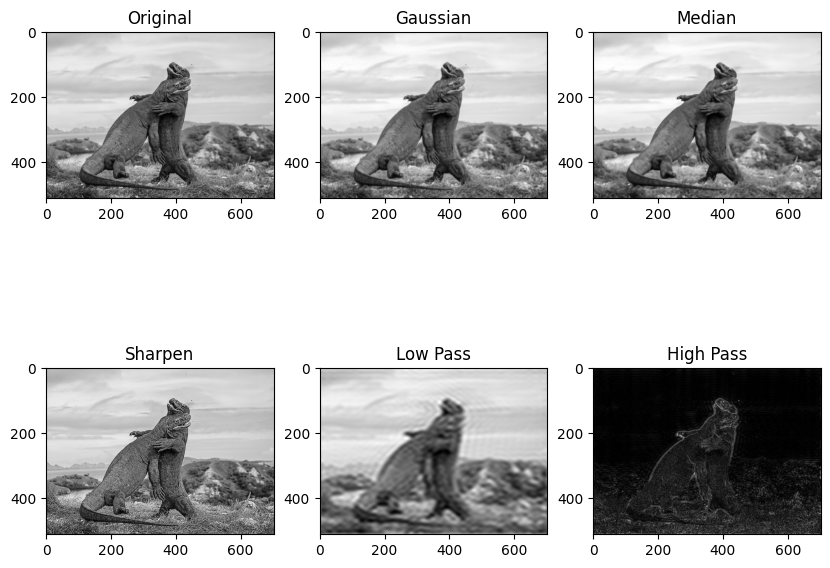

In [30]:
plt.figure(figsize=(10,8))

plt.subplot(2,3,1), plt.imshow(img, cmap='gray'), plt.title('Original')
plt.subplot(2,3,2), plt.imshow(gaussian, cmap='gray'), plt.title('Gaussian')
plt.subplot(2,3,3), plt.imshow(median, cmap='gray'), plt.title('Median')
plt.subplot(2,3,4), plt.imshow(sharpen, cmap='gray'), plt.title('Sharpen')
plt.subplot(2,3,5), plt.imshow(img_back, cmap='gray'), plt.title('Low Pass')
plt.subplot(2,3,6), plt.imshow(img_high, cmap='gray'), plt.title('High Pass')

plt.show()